# Admin Dashboard Notebook

Compact notebook for demo/viva:
- top contributors
- team health panels
- fairness/bias summary

In [6]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_GRAPHS = PROJECT_ROOT / "outputs" / "graphs"

student_scores = pd.read_csv(DATA_PROCESSED / "student_scores.csv")
team_metrics = pd.read_csv(DATA_PROCESSED / "team_metrics.csv")

sns.set_theme(style="whitegrid")
student_scores.head()

,student_id,student_name,team_id,contribution_score,team_rank,progress_score,attendance_ratio,task_completion_rate,bias_flag,disagreement_score
0,S004,Meera,T01,76.533660,1.0,42.25,0.8,0.916667,Aligned,23.091300
1,S002,Diya,T01,70.605454,2.0,44.50,0.7,0.750000,Aligned,6.000158
2,S003,Ishan,T01,68.227273,3.0,38.25,0.9,0.700000,Potential Bias,35.000000
3,S005,Rohan,T01,58.688175,4.0,41.25,0.7,0.875000,Aligned,9.935213
4,S001,Aarav,T01,42.869610,5.0,46.25,0.9,0.666667,Aligned,13.074326


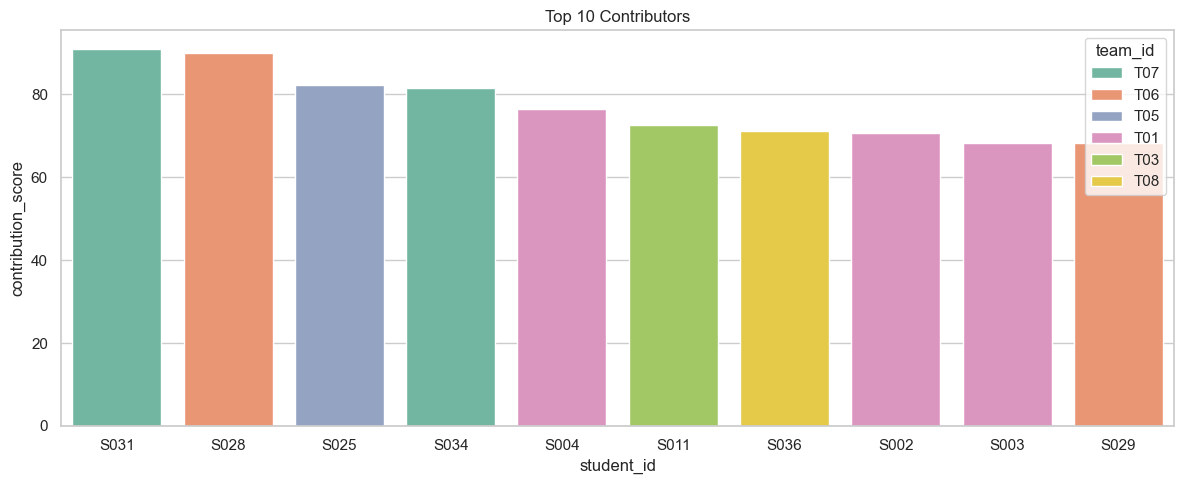

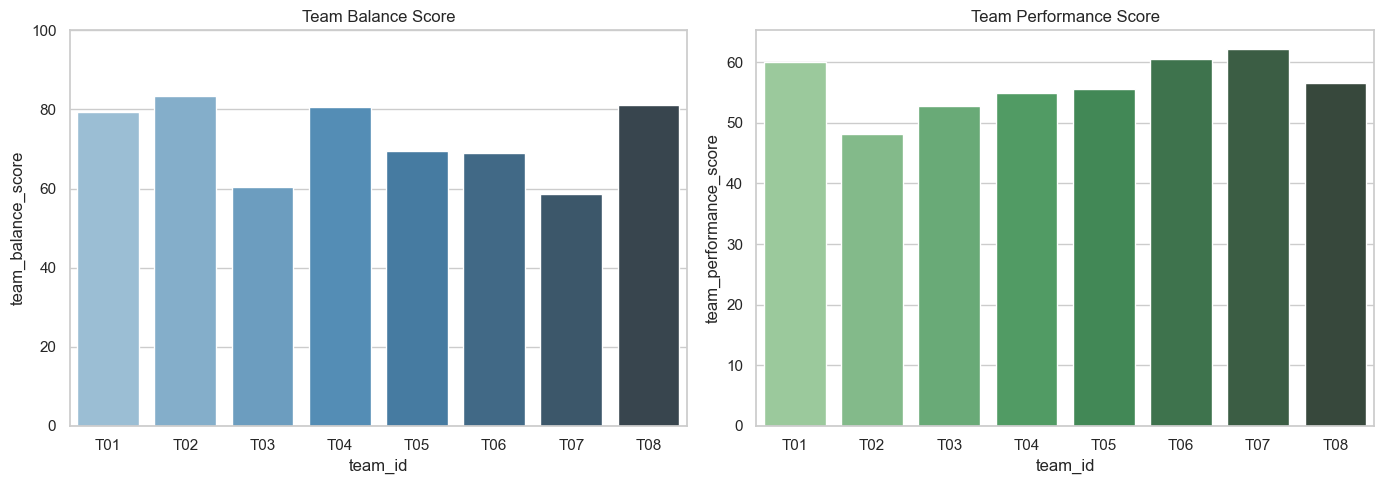

In [7]:
# Top contributors view
plt.figure(figsize=(12, 5))
top10 = student_scores.sort_values("contribution_score", ascending=False).head(10)
sns.barplot(data=top10, x="student_id", y="contribution_score", hue="team_id", palette="Set2")
plt.title("Top 10 Contributors")
plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / "dashboard_top10_contributors.png", dpi=150)
plt.show()

# Team health view
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=team_metrics, x="team_id", y="team_balance_score", hue="team_id", ax=axes[0], palette="Blues_d", legend=False)
axes[0].set_title("Team Balance Score")
axes[0].set_ylim(0, 100)

sns.barplot(data=team_metrics, x="team_id", y="team_performance_score", hue="team_id", ax=axes[1], palette="Greens_d", legend=False)
axes[1].set_title("Team Performance Score")
plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / "dashboard_team_health.png", dpi=150)
plt.show()

In [8]:
# Risk and fairness snapshot
risk_table = team_metrics[["team_id", "risk_flag", "team_balance_score", "team_delay_indicator"]].sort_values(["risk_flag", "team_balance_score"])
print("Team Risk Snapshot")
display(risk_table)

bias_cases = student_scores[student_scores["bias_flag"] == "Potential Bias"].sort_values("disagreement_score", ascending=False)
print("Potential Bias Cases")
display(bias_cases.head(15))

Team Risk Snapshot


,team_id,risk_flag,team_balance_score,team_delay_indicator
6,T07,At-Risk,58.66,19.6
2,T03,At-Risk,60.38,25.6
5,T06,At-Risk,69.03,25.4
4,T05,At-Risk,69.38,26.2
0,T01,At-Risk,79.26,28.6
3,T04,Stable,80.57,20.4
7,T08,Stable,81.13,23.8
1,T02,Stable,83.47,24.8


Potential Bias Cases


,student_id,student_name,team_id,contribution_score,team_rank,progress_score,attendance_ratio,task_completion_rate,bias_flag,disagreement_score
28,S026,Harsh,T06,48.856494,4.0,46.25,0.7,0.833333,Potential Bias,50.711310
23,S021,Aditya,T05,44.349893,4.0,36.25,0.5,0.583333,Potential Bias,47.879990
31,S034,Om,T07,81.482546,2.0,44.50,0.9,1.000000,Potential Bias,45.125032
2,S003,Ishan,T01,68.227273,3.0,38.25,0.9,0.700000,Potential Bias,35.000000
12,S014,Pooja,T03,39.544573,3.0,48.25,0.5,0.750000,Potential Bias,34.052877
24,S023,Reyansh,T05,38.116296,5.0,43.00,0.8,0.571429,Potential Bias,30.619510
36,S038,Varun,T08,57.952720,2.0,45.25,0.8,0.666667,Potential Bias,29.643388
21,S022,Saanvi,T05,55.626969,2.0,59.50,0.5,0.769231,Potential Bias,28.373648
18,S018,Neha,T04,42.244137,4.0,42.50,0.5,0.714286,Potential Bias,26.524167
